ESERNet

Using device: cuda
Assumed preprocessed data root: /kaggle/input/speech-emotion-10/VESC/VESC
Assumed preprocessed data test root: /kaggle/input/speech-emotion-10/VESC_test/VESC_test
Loaded 672 samples from 5 emotion classes from /kaggle/input/speech-emotion-10/VESC/VESC.
Loaded 232 samples from 5 emotion classes from /kaggle/input/speech-emotion-10/VESC_test/VESC_test.
Scaler successfully fitted on individual Mel values.
Scaler successfully fitted on individual Mel values.
Number of training samples: 537
Number of validation samples: 135
Number of test samples: 232
Number of emotion classes: 5

Starting training...
Epoch 1/50:
   Train Loss: 0.7697, Train Acc: 0.4060
   Val Loss: 0.6919, Val Acc: 0.4296, Val UA: 0.4324
   Saving best model!
Epoch 2/50:
   Train Loss: 0.6264, Train Acc: 0.5158
   Val Loss: 0.5006, Val Acc: 0.6148, Val UA: 0.5888
   Saving best model!
Epoch 3/50:
   Train Loss: 0.5377, Train Acc: 0.6145
   Val Loss: 0.5749, Val Acc: 0.5111, Val UA: 0.4665
Epoch 4/50:
   

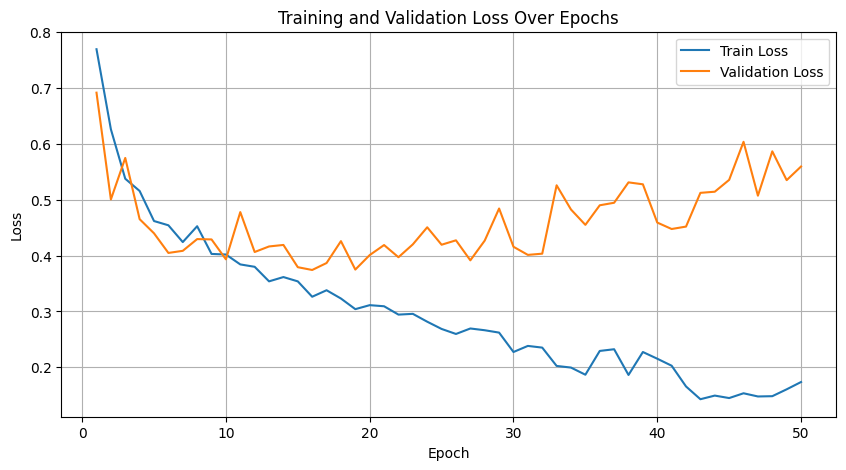

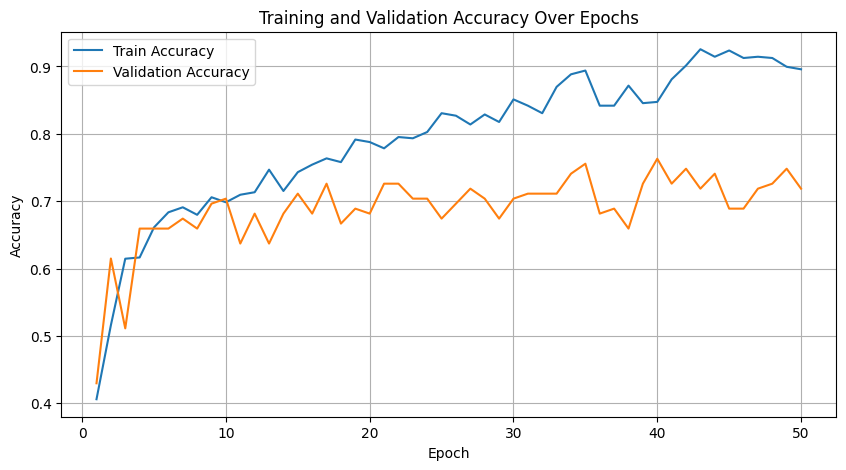


Evaluating best model on test set...

Results on test set:
   Test Loss: 0.4761
   Test Accuracy (ACC): 0.7069
   Test Unweighted Accuracy (UA): 0.7154
   Test Precision (Weighted): 0.7383
   Test Recall (Weighted): 0.7069
   Test F1-score (Weighted): 0.7124

Classification Report:
              precision    recall  f1-score   support

       Angry     0.8000    0.8649    0.8312        37
       Happy     0.5614    0.7273    0.6337        44
     Anxiety     0.2963    0.4000    0.3404        20
     Neutral     0.8857    0.9688    0.9254        32
         Sad     0.8356    0.6162    0.7093        99

    accuracy                         0.7069       232
   macro avg     0.6758    0.7154    0.6880       232
weighted avg     0.7383    0.7069    0.7124       232



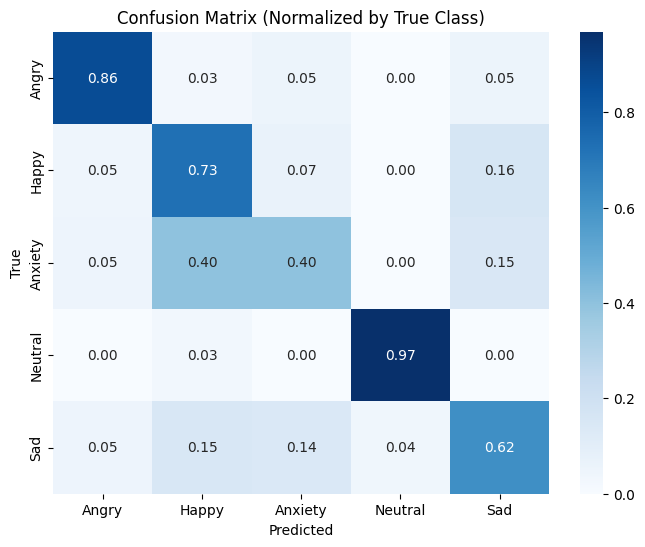

In [5]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import random
import soundfile as sf # Needed if generating dummy data in the same notebook

# --- 1. Configuration and Environment Setup ---
# Ensure reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameter configuration (needs fine-tuning based on the paper and experiments)
SAMPLE_RATE = 16000     # Common sample rate for speech data
N_MELS = 128            # Number of Mel bins for Mel-spectrogram
MAX_AUDIO_DURATION = 3  # Seconds. E.g., 3 seconds. Needs to be estimated or taken as max from dataset.
# The number of frames (columns) in the Mel-spectrogram.
# Assuming default librosa.feature.melspectrogram parameters (n_fft=2048, hop_length=512)
# For 3s audio at 16000Hz, len(audio) = 3 * 16000 = 48000
# Number of frames = floor(48000 / 512) + 1 = 93 + 1 = 94.
# MAX_SEQ_LEN = 250 is appropriate for longer segments or if you're using a smaller hop_length.
MAX_SEQ_LEN = 250
MASK_RATE = 0.15        # Masking ratio for Key Cue Pathway
PI_BALANCE = 0.5        # Hyperparameter π to balance the loss functions

BATCH_SIZE = 16
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

# Transformer configuration
NUM_TRANSFORMER_BLOCKS = 4 # M in the paper
EMBED_DIM = N_MELS # Embedding dimension, can be different from N_MELS if a Linear layer is used
NUM_HEADS = 8


# --- 2. Data Preprocessing and Dataset ---

# Emotion label mapping for consistency
# This mapping was used to organize the folders

EMOTION_TO_INT_EMODB = {
    'Angry': 0,
    'Happy': 1,
    'Anxiety': 2,
    'Neutral': 3,
    'Sad': 4
}

INT_TO_EMOTION_EMODB = {v: k for k, v in EMOTION_TO_INT_EMODB.items()}
NUM_EMOTIONS_EMODB = len(EMOTION_TO_INT_EMODB)


class SpeechEmotionDataset(Dataset):
    def __init__(self, audio_paths, labels, sample_rate, n_mels, max_seq_len, transform=None):
        self.audio_paths = audio_paths
        self.labels = labels
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.max_seq_len = max_seq_len
        self.transform = transform
        self.scaler = StandardScaler()
        self._fit_scaler()

    def _fit_scaler(self):
        # Collect a small subset of Mel values to fit the scaler
        # Instead of flattening the whole spectrogram, we collect all Mel values
        # from a subset of samples and fit the scaler on them.
        all_mel_values = []
        # Ensure there are enough audio_paths to sample from
        if not self.audio_paths:
            print("Warning: No audio paths provided. Cannot fit scaler.")
            self.scaler.mean_ = np.zeros(1)
            self.scaler.scale_ = np.ones(1)
            return

        sample_indices = random.sample(range(len(self.audio_paths)), min(100, len(self.audio_paths)))
        
        for i in sample_indices:
            try:
                audio, sr = librosa.load(self.audio_paths[i], sr=self.sample_rate)
                mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=self.n_mels)
                mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max) # Convert to dB
                all_mel_values.extend(mel_spectrogram.flatten())
            except Exception as e:
                # print(f"Warning: Could not load or process file {self.audio_paths[i]} to fit scaler. Error: {e}")
                continue    
        
        if all_mel_values:
            # Fit scaler on all collected Mel values
            self.scaler.fit(np.array(all_mel_values).reshape(-1, 1))
            print("Scaler successfully fitted on individual Mel values.")
        else:
            print("Warning: Not enough data to fit scaler. Using default StandardScaler or manual initialization.")
            self.scaler.mean_ = np.zeros(1)
            self.scaler.scale_ = np.ones(1)


    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = self.labels[idx]

        try:
            audio, sr = librosa.load(audio_path, sr=self.sample_rate)
            
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=self.n_mels)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max) # Convert to dB

            # Normalize spectrogram
            if hasattr(self.scaler, 'mean_') and self.scaler.mean_ is not None:
                # Apply scaler across the entire spectrogram
                mel_spectrogram = self.scaler.transform(mel_spectrogram.reshape(-1, 1)).reshape(mel_spectrogram.shape)
            
            # Pad or truncate to a uniform length
            if mel_spectrogram.shape[1] < self.max_seq_len:
                pad_width = self.max_seq_len - mel_spectrogram.shape[1]
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, pad_width)), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :self.max_seq_len]
            
            mel_spectrogram = torch.tensor(mel_spectrogram, dtype=torch.float32)

            return mel_spectrogram, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            print(f"Error loading or processing file {audio_path}: {e}")
            # Error handling: Return a zero tensor and -1 label to indicate a faulty sample
            return torch.zeros(self.n_mels, self.max_seq_len), torch.tensor(-1, dtype=torch.long)


# --- Function to load data from labeled subfolders ---
def load_data_from_folders(base_path, emotion_to_int_map):
    audio_paths = []
    labels = []
    
    # Sort folder names to ensure consistent integer label order
    sorted_emotion_names = sorted(emotion_to_int_map.keys())
    
    for emotion_name in sorted_emotion_names:
        emotion_folder_path = os.path.join(base_path, emotion_name)
        if not os.path.isdir(emotion_folder_path):
            print(f"Warning: Folder '{emotion_folder_path}' not found. Skipping.")
            continue
            
        label_int = emotion_to_int_map[emotion_name]
        
        for filename in os.listdir(emotion_folder_path):
            if filename.endswith(".wav"):
                full_path = os.path.join(emotion_folder_path, filename)
                audio_paths.append(full_path)
                labels.append(label_int)
    
    num_emotions = len(emotion_to_int_map)
    print(f"Loaded {len(audio_paths)} samples from {num_emotions} emotion classes from {base_path}.")
    return audio_paths, labels, num_emotions

# --- Function to generate dummy data (only for testing if no real data is available) ---
def generate_dummy_data(num_samples=100, num_emotions=7):
    dummy_audio_dir = "dummy_audio"
    os.makedirs(dummy_audio_dir, exist_ok=True)
    audio_paths = []
    labels = []
    
    for i in range(num_samples):
        # Generate dummy audio with random duration between 1-MAX_AUDIO_DURATION seconds
        dummy_audio = np.random.randn(SAMPLE_RATE * random.randint(1, MAX_AUDIO_DURATION)).astype(np.float32)
        file_path = os.path.join(dummy_audio_dir, f"audio_{i:03d}.wav")
        try:
            sf.write(file_path, dummy_audio, SAMPLE_RATE)
            audio_paths.append(file_path)
            labels.append(random.randint(0, num_emotions - 1))
        except Exception as e:
            print(f"Error creating dummy file {file_path}: {e}")
            continue
    
    return audio_paths, labels, num_emotions


# --- 3. ESERNet Model Architecture ---

# Helper Modules for Transformer
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        assert self.head_dim * num_heads == self.embed_dim, "embed_dim must be divisible by num_heads"
        
        # Tách riêng các lớp chiếu cho Q, K, V để hỗ trợ cross-attention
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, query, context=None, mask=None):
        # query: (batch_size, seq_len_q, embed_dim)
        # context: (batch_size, seq_len_k, embed_dim)
        
        if context is None:
            context = query  # Trường hợp self-attention

        batch_size_q, seq_len_q, _ = query.size()
        batch_size_c, seq_len_k, _ = context.size()

        # Chiếu và thay đổi hình dạng
        q = self.q_proj(query).reshape(batch_size_q, seq_len_q, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        k = self.k_proj(context).reshape(batch_size_c, seq_len_k, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        v = self.v_proj(context).reshape(batch_size_c, seq_len_k, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        # q: (B, num_heads, seq_len_q, head_dim)
        # k,v: (B, num_heads, seq_len_k, head_dim)
        
        energy = torch.matmul(q, k.transpose(-1, -2)) / (self.head_dim ** 0.5)
        
        if mask is not None:
            # Mask phải có kích thước phù hợp với energy (B, num_heads, seq_len_q, seq_len_k)
            # Mask đầu vào thường là (B, seq_len_k)
            mask_expanded = (mask.unsqueeze(1).unsqueeze(2) == 1) # (B, 1, 1, seq_len_k)
            energy = energy.masked_fill(mask_expanded, float('-inf'))

        attention = F.softmax(energy, dim=-1)
        
        out = torch.matmul(attention, v)
        out = out.permute(0, 2, 1, 3).reshape(batch_size_q, seq_len_q, self.embed_dim)
        
        out = self.out_proj(out)
        return out

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        # Sử dụng lớp mới
        self.attention = MultiHeadAttention(embed_dim, num_heads)
        self.dropout1 = nn.Dropout(dropout)
        
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        norm_x = self.norm1(x)
        # Lớp mới xử lý self-attention khi context=None, nên không cần thay đổi cách gọi
        attn_output = self.attention(norm_x, mask=mask)
        x = x + self.dropout1(attn_output)

        norm_x = self.norm2(x)
        ffn_output = self.ffn(norm_x)
        x = x + self.dropout2(ffn_output)
        return x


# --- Helper Modules for the new Relationship Pathway ---

class WordObjectEncoderStep(nn.Module):
    """
    Implements one step of the Word and Object Encoder logic from the paper.
    It processes an input feature map to extract coarse-grained information using
    non-overlapping and overlapping windows.
    """
    def __init__(self, embed_dim, num_heads, num_word_tokens, window_size):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_word_tokens = num_word_tokens
        self.window_size = window_size # N_oi in the paper

        self.word_tokens = nn.Parameter(torch.randn(1, num_word_tokens, embed_dim))
        
        self.word_encoder_mhsa = MultiHeadAttention(embed_dim, num_heads)
        self.object_encoder_mhsa = MultiHeadAttention(embed_dim, num_heads)
        
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        
        # --- Word Encoder ---
        segment_len = seq_len // self.num_word_tokens
        if segment_len == 0: # 
             pooled_segments = x.mean(dim=1).unsqueeze(1).repeat(1, self.num_word_tokens, 1)
        else:
            non_overlapping_segments = x[:, :self.num_word_tokens * segment_len].reshape(
                batch_size * self.num_word_tokens, segment_len, self.embed_dim
            )
            pooled_segments = non_overlapping_segments.mean(dim=1).reshape(batch_size, self.num_word_tokens, self.embed_dim)
        
        expanded_tokens = self.word_tokens.expand(batch_size, -1, -1)
        
        updated_tokens = self.word_encoder_mhsa(query=expanded_tokens, context=pooled_segments)

        # --- Object Encoder ---
        x_permuted = x.permute(0, 2, 1)
        if seq_len < self.window_size:
            padding = self.window_size - seq_len
            x_permuted = F.pad(x_permuted, (0, padding))

        overlapping_segments = x_permuted.unfold(dimension=2, size=self.window_size, step=1).permute(0, 2, 3, 1)
        num_windows = overlapping_segments.size(1)
        object_tokens = overlapping_segments[:, :, self.window_size // 2, :]

        context_tokens = updated_tokens.mean(dim=1).unsqueeze(1).repeat(1, num_windows, 1)
        
        attn_input = torch.cat((object_tokens, context_tokens), dim=-1)
        attended_features = self.object_encoder_mhsa(query=object_tokens, context=updated_tokens)
        
        final_features = attended_features

        out = self.norm1(final_features)
        out = out + self.ffn(self.norm2(out))
        
        return out

class CombinedBlock(nn.Module):
    """
    Implements the Combined Block from the paper.
    It uses pooling to reduce sequence length and projects features
    for the next step in the hierarchy.
    """
    def __init__(self, in_dim, out_dim, pool_size):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(pool_size)
        self.proj = nn.Linear(in_dim, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, embed_dim)
        x_permuted = x.permute(0, 2, 1) # (B, C, L)
        pooled = self.pool(x_permuted).permute(0, 2, 1) # (B, new_L, C)
        projected = self.proj(pooled)
        normalized = self.norm(projected)
        return normalized
# --- ESERNet Model ---
class ESERNet(nn.Module):
    def __init__(self, n_mels, max_seq_len, embed_dim, num_heads, num_transformer_blocks, num_emotions, mask_rate):
        super().__init__()
        self.n_mels = n_mels
        self.max_seq_len = max_seq_len
        self.embed_dim = embed_dim
        self.mask_rate = mask_rate

        self.input_linear = nn.Linear(n_mels, embed_dim) if n_mels != embed_dim else nn.Identity()

        # --- Key Cue Pathway (Unchanged) ---
        self.mask_embedding_linear = nn.Linear(1, embed_dim)
        self.key_cue_transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, embed_dim * 4) for _ in range(num_transformer_blocks)
        ])
        self.recover_linear = nn.Linear(embed_dim, n_mels)

        # --- Relationship Pathway (REVISED to be Hierarchical) ---
        # The paper mentions 3 steps, moving from frames to words.
        # We define the parameters for each step of the hierarchy.
        
        # Step I (Fine-grained: e.g., frames)
        self.encoder_step1 = WordObjectEncoderStep(embed_dim, num_heads, num_word_tokens=16, window_size=5)
        # Combined block to downsample for Step 2. Paper mentions 50ms pooling.
        pool_size_1 = max(1, int(max_seq_len * 0.5)) # Downsample by half
        self.combiner1 = CombinedBlock(embed_dim, embed_dim, pool_size_1)
        
        # Step II (Medium-grained: e.g., phonemes/syllables)
        self.encoder_step2 = WordObjectEncoderStep(embed_dim, num_heads, num_word_tokens=8, window_size=7)
        # Combined block to downsample for Step 3. Paper mentions 250ms pooling.
        pool_size_2 = max(1, int(pool_size_1 * 0.5)) # Downsample by half again
        self.combiner2 = CombinedBlock(embed_dim, embed_dim, pool_size_2)

        # Step III (Coarse-grained: e.g., words)
        self.encoder_step3 = WordObjectEncoderStep(embed_dim, num_heads, num_word_tokens=4, window_size=9)
        
        # Final M Transformer blocks to process the final hierarchical features
        self.relationship_transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, embed_dim * 4) for _ in range(num_transformer_blocks)
        ])
        
        # --- Classifier (Unchanged) ---
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, num_emotions)
        )

    def forward(self, x):
        # x: (batch_size, n_mels, max_seq_len)
        batch_size, _, seq_len = x.size()
        
        # Initial projection and embedding
        x_permuted = x.permute(0, 2, 1) # (B, S_len, n_mels)
        x_embed = self.input_linear(x_permuted) # (B, S_len, embed_dim)

        # --- Key Cue Pathway (Unchanged logic) ---
        mask = torch.zeros(batch_size, seq_len, dtype=torch.float32).to(x.device)
        num_masked_tokens = min(seq_len, int(seq_len * self.mask_rate))
        if self.training: # Only apply mask during training
            for i in range(batch_size):
                if num_masked_tokens > 0:
                    indices_to_mask = random.sample(range(seq_len), num_masked_tokens)
                    mask[i, indices_to_mask] = 1.0
        
        s_m = x_embed * (1 - mask).unsqueeze(-1)
        s_prime_key_cue = s_m + self.mask_embedding_linear(mask.unsqueeze(-1))
        for block in self.key_cue_transformer_blocks:
            s_prime_key_cue = block(s_prime_key_cue, mask=mask)
        recovered_spectrogram = self.recover_linear(s_prime_key_cue).permute(0, 2, 1)

        # --- Relationship Pathway (REVISED with Hierarchical Structure) ---
        # Step 1
        rel_features = self.encoder_step1(x_embed)
        rel_features = self.combiner1(rel_features)
        
        # Step 2
        rel_features = self.encoder_step2(rel_features)
        rel_features = self.combiner2(rel_features)

        # Step 3
        rel_features = self.encoder_step3(rel_features)

        # Final M Transformer Blocks
        for block in self.relationship_transformer_blocks:
            rel_features = block(rel_features)
        
        # Get final features for classification (mean pooling over the final sequence)
        final_pooled_features = rel_features.mean(dim=1) # (batch_size, embed_dim)
        
        # Classifier
        logits = self.classifier(final_pooled_features)

        return recovered_spectrogram, logits, mask

# --- 4. Model Training ---

def train_epoch(model, dataloader, optimizer, criterion_L1, criterion_L2, pi_balance, device):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    filtered_batches = []
    for mel_spectrograms, labels in dataloader:
        valid_indices = (labels != -1).nonzero(as_tuple=True)[0]
        if valid_indices.numel() > 0:
            filtered_batches.append((mel_spectrograms[valid_indices], labels[valid_indices]))

    for i, (mel_spectrograms, labels) in enumerate(filtered_batches):
        mel_spectrograms = mel_spectrograms.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        recovered_spectrogram, logits, mask = model(mel_spectrograms)

        # L1 Loss (Key Cue Pathway)
        # Calculate MSE only on masked regions
        mask_expanded_for_mse = mask.unsqueeze(1).repeat(1, N_MELS, 1)
        
        loss_L1 = criterion_L1(recovered_spectrogram * mask_expanded_for_mse, 
                               mel_spectrograms * mask_expanded_for_mse)

        # L2 Loss (Relationship Pathway / Classification)
        loss_L2 = criterion_L2(logits, labels)

        # Total Loss
        loss = (1 - pi_balance) * loss_L1 + pi_balance * loss_L2
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    avg_loss = total_loss / len(filtered_batches) if filtered_batches else 0
    accuracy = correct_predictions / total_samples if total_samples else 0
    return avg_loss, accuracy

def evaluate_model(model, dataloader, criterion_L1, criterion_L2, pi_balance, device, num_emotions):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    filtered_batches = []
    for mel_spectrograms, labels in dataloader:
        valid_indices = (labels != -1).nonzero(as_tuple=True)[0]
        if valid_indices.numel() > 0:
            filtered_batches.append((mel_spectrograms[valid_indices], labels[valid_indices]))

    with torch.no_grad():
        for mel_spectrograms, labels in filtered_batches:
            mel_spectrograms = mel_spectrograms.to(device)
            labels = labels.to(device)

            recovered_spectrogram, logits, mask = model(mel_spectrograms)
            
            mask_expanded_for_mse = mask.unsqueeze(1).repeat(1, N_MELS, 1)
            loss_L1 = criterion_L1(recovered_spectrogram * mask_expanded_for_mse, 
                                   mel_spectrograms * mask_expanded_for_mse)
            loss_L2 = criterion_L2(logits, labels)
            loss = (1 - pi_balance) * loss_L1 + pi_balance * loss_L2
            
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_loss = total_loss / len(filtered_batches) if filtered_batches else 0
    accuracy = correct_predictions / total_samples if total_samples else 0
    
    # Calculate other metrics: precision, recall, f1-score
    # 'weighted' average accounts for class imbalance
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    
    # Calculate Unweighted Accuracy (UA)
    class_accuracies = []
    for i in range(num_emotions):
        class_labels_mask = np.array(all_labels) == i
        if np.sum(class_labels_mask) > 0:
            class_preds_for_class = np.array(all_preds)[class_labels_mask]
            class_correct = np.sum(class_preds_for_class == i)
            class_accuracy = class_correct / np.sum(class_labels_mask)
            class_accuracies.append(class_accuracy)
    ua = np.mean(class_accuracies) if class_accuracies else 0

    # Calculate per-class F1-scores
    per_class_f1_scores = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)[2]
    
    return avg_loss, accuracy, ua, precision, recall, f1, all_labels, all_preds, per_class_f1_scores

# --- Main Function ---
def main(processed_data_path, datatest_path):
    num_emotions = NUM_EMOTIONS_EMODB  
    
    audio_paths, labels, _ = load_data_from_folders(processed_data_path, EMOTION_TO_INT_EMODB)
    audiotest_paths, labelstest, _ = load_data_from_folders(datatest_path, EMOTION_TO_INT_EMODB)
    
    # If no real data is found (e.g., path error), generate dummy data to proceed
    if not audio_paths:
        print("No real data found at the specified training path. Generating dummy training data to proceed.")
        # Ensure dummy data matches your expected number of emotions
        audio_paths, labels, _ = generate_dummy_data(num_samples=200, num_emotions=num_emotions)
    
    if not audiotest_paths:
        print("No real data found at the specified test path. Generating dummy test data to proceed.")
        audiotest_paths, labelstest, _ = generate_dummy_data(num_samples=50, num_emotions=num_emotions)


    dataset = SpeechEmotionDataset(audio_paths, labels, SAMPLE_RATE, N_MELS, MAX_SEQ_LEN)
    datatest = SpeechEmotionDataset(audiotest_paths, labelstest, SAMPLE_RATE, N_MELS, MAX_SEQ_LEN)

    # Split the main 'dataset' into training and validation sets
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size # Ensure that train_size + val_size equals len(dataset)
    
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    test_dataset = datatest # Assign the separate 'datatest' dataset to 'test_dataset'

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Number of training samples: {len(train_dataset)}")
    print(f"Number of validation samples: {len(val_dataset)}")
    print(f"Number of test samples: {len(test_dataset)}")
    print(f"Number of emotion classes: {num_emotions}")

    model = ESERNet(N_MELS, MAX_SEQ_LEN, EMBED_DIM, NUM_HEADS, NUM_TRANSFORMER_BLOCKS, num_emotions, MASK_RATE).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    criterion_L1 = nn.MSELoss() # For Key Cue Pathway
    criterion_L2 = nn.CrossEntropyLoss() # For Relationship Pathway / Classification

    best_val_accuracy = 0.0

    # Lists to store loss and accuracy history for plotting
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    print("\nStarting training...")
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion_L1, criterion_L2, PI_BALANCE, device)
        
        # Check if val_loader has data before evaluating
        if len(val_loader) > 0:
            val_loss, val_acc, val_ua, val_prec, val_rec, val_f1, _, _, _ = evaluate_model(model, val_loader, criterion_L1, criterion_L2, PI_BALANCE, device, num_emotions)
        else:
            print("Warning: Validation loader is empty. Skipping validation for this epoch.")
            val_loss, val_acc, val_ua, val_prec, val_rec, val_f1 = 0, 0, 0, 0, 0, 0 # Default values if no validation set
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
        print(f"   Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"   Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val UA: {val_ua:.4f}")
        
        # Save the best model based on validation accuracy (only if validation data exists)
        if len(val_loader) > 0 and val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            torch.save(model.state_dict(), "best_esernet_model.pth")
            print("   Saving best model!")
        elif len(val_loader) == 0:
            print("   Skipping best model saving due to empty validation set.")

    print("\nTraining complete.")

    # Plotting Loss History
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss')
    plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plotting Accuracy History
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, label='Train Accuracy')
    plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()


    # --- 5. Model Evaluation ---
    if os.path.exists("best_esernet_model.pth"):
        print("\nEvaluating best model on test set...")
        model.load_state_dict(torch.load("best_esernet_model.pth"))
        
        # Check if test_loader has data before evaluating
        if len(test_loader) > 0:
            test_loss, test_acc, test_ua, test_prec, test_rec, test_f1, all_labels, all_preds, per_class_f1_scores = evaluate_model(model, test_loader, criterion_L1, criterion_L2, PI_BALANCE, device, num_emotions)
        else:
            print("No test set available for evaluation.")
            test_loss, test_acc, test_ua, test_prec, test_rec, test_f1, all_labels, all_preds, per_class_f1_scores = 0,0,0,0,0,0,[],[],[]


        print(f"\nResults on test set:")
        print(f"   Test Loss: {test_loss:.4f}")
        print(f"   Test Accuracy (ACC): {test_acc:.4f}")
        print(f"   Test Unweighted Accuracy (UA): {test_ua:.4f}")
        print(f"   Test Precision (Weighted): {test_prec:.4f}")
        print(f"   Test Recall (Weighted): {test_rec:.4f}")
        print(f"   Test F1-score (Weighted): {test_f1:.4f}")

        # Report F1-score per label
        if all_labels and all_preds:
            # Generate the list of target names in the correct order for the report
            target_names = [INT_TO_EMOTION_EMODB[i] for i in sorted(INT_TO_EMOTION_EMODB.keys())]
            
            # Generate and print the classification report
            report = classification_report(all_labels, all_preds, target_names=target_names, digits=4, zero_division=0)
            print("\nClassification Report:")
            print(report)

        # Generate Confusion Matrix
        if all_labels and all_preds:
            cm = confusion_matrix(all_labels, all_preds)
            # Normalize the confusion matrix to percentages (recall for each true class)
            cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", # Use fmt=".2f" for 2 decimal places
                        xticklabels=[INT_TO_EMOTION_EMODB[i] for i in sorted(INT_TO_EMOTION_EMODB.keys())],
                        yticklabels=[INT_TO_EMOTION_EMODB[i] for i in sorted(INT_TO_EMOTION_EMODB.keys())])
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.title("Confusion Matrix (Normalized by True Class)")
            plt.show()
        else:
            print("Not enough data to generate Confusion Matrix.")
    else:
        print("No best model found for evaluation.")

# --- Call main function to start the program ---
if __name__ == "__main__":
    # This is the path where your preprocessed and organized EmoDB data
    # should be located after running your preprocessing notebook.
    # On Kaggle, the output of another notebook is typically mounted under /kaggle/input/
    # and will have a path like /kaggle/input/your-username/your-old-notebook-name/your-output-folder/
    
    # REPLACE THE LINE BELOW WITH YOUR ACTUAL KAGGLE PATH
    # Example: if your preprocessing notebook's output is 'emodb_processed_by_label'
    # and your preprocessing notebook is named 'emodb-preprocessing-notebook',
    # the path might be:
    PROCESSED_DATA_ROOT = "/kaggle/input/speech-emotion-10/VESC/VESC" # REPLACE THIS PATH
    PROCESSED_DATA_TEST_ROOT = '/kaggle/input/speech-emotion-10/VESC_test/VESC_test'
    print(f"Assumed preprocessed data root: {PROCESSED_DATA_ROOT}")
    print(f"Assumed preprocessed data test root: {PROCESSED_DATA_TEST_ROOT}")
    main(processed_data_path=PROCESSED_DATA_ROOT, datatest_path=PROCESSED_DATA_TEST_ROOT)